<a href="https://colab.research.google.com/github/zbnisa12-maker/week1_lab-/blob/main/CSE206_Lab_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSE206 Fundamental of Machine Learning

## Lab: Linear Regression with Gradient Descent
### Predicting house price from area

**Duration:** 2 hours

| Session | Part | Time |
|---|---|---|
| Session 1 | Part A: Guided walkthrough | about 60 minutes |
| Session 2 | Part B: Graded exercises | about 60 minutes |

**Learning outcomes.** By the end of this lab you will be able to:

1. Explain what a linear regression model is.
2. Measure how good a line is using a cost function.
3. Use gradient descent to find the best line, step by step.
4. Plot the regression line and the cost-convergence curve.
5. Use the trained model to predict the price of a new house.

**How to use this notebook**

- Run the cells in order, from top to bottom. To run a cell, click on it and press **Shift + Enter**.
- If you see an error such as `NameError: name '...' is not defined`, you probably skipped a cell above. Go back and run it.

---
# Part A: Guided Walkthrough (Session 1)

In this part we build a linear regression model together, one small step at a time.

## A1. The problem

A real-estate agent wants a quick way to estimate the price of a house from its **area** (size in square metres).

We know from experience that bigger houses usually cost more. We have data about houses that were already sold. We want the computer to learn a simple rule from this data:

> give it the area of a house, and it gives back an estimated price.

**Linear regression** does this by finding the **straight line** that best fits the data.

Words we will use:

| Word | Meaning in this lab |
|---|---|
| Feature (input), `x` | The area of the house |
| Target (output), `y` | The price of the house |
| Model | The straight line that turns area into price |
| Training | Finding the best line from the data |
| Prediction | Using the line to estimate the price of a new house |

## A2. Import the libraries

- **NumPy** helps us work with lists of numbers (arrays).
- **Matplotlib** helps us draw plots.

In [2]:
import numpy as np                 # for working with arrays of numbers
import matplotlib.pyplot as plt    # for drawing plots

print("Libraries loaded.")

Libraries loaded.


## A3. The data

We have **10 houses**.

- Area is in square metres (m2).
- Price is in **thousand US dollars**. So `150` means $150,000.

In [3]:
area = np.array([50, 60, 70, 80, 90, 100, 110, 120, 140, 160])       # m2
price = np.array([110, 125, 150, 160, 185, 200, 215, 240, 270, 310])  # thousand $

print("Number of houses:", len(area))
print()
for i in range(len(area)):
    print("House", i + 1, ": area =", area[i], "m2,  price =", price[i], "thousand $")

Number of houses: 10

House 1 : area = 50 m2,  price = 110 thousand $
House 2 : area = 60 m2,  price = 125 thousand $
House 3 : area = 70 m2,  price = 150 thousand $
House 4 : area = 80 m2,  price = 160 thousand $
House 5 : area = 90 m2,  price = 185 thousand $
House 6 : area = 100 m2,  price = 200 thousand $
House 7 : area = 110 m2,  price = 215 thousand $
House 8 : area = 120 m2,  price = 240 thousand $
House 9 : area = 140 m2,  price = 270 thousand $
House 10 : area = 160 m2,  price = 310 thousand $


## A4. Look at the data

Before building any model, we should always **plot the data** and look at it.

A **scatter plot** draws one dot for each house.

In [ ]:
plt.scatter(area, price)
plt.xlabel("Area (m2)")
plt.ylabel("Price (thousand $)")
plt.title("House price vs area")
plt.grid(True)
plt.show()

**What do we see?**

- The dots go **up from left to right**: bigger area, higher price.
- The dots lie **almost on a straight line**.

So a straight line is a sensible model for this data.

## A5. Prepare the input (scaling)

Our areas are numbers like 50, 100, 160. Gradient descent (the method we will use) works much better when the input numbers are **small, around 1**.

A simple fix: **change the unit**. Instead of square metres, we measure area in **hundreds of square metres**. We just divide by 100.

| Area (m2) | x = area / 100 |
|---|---|
| 50 | 0.5 |
| 120 | 1.2 |
| 160 | 1.6 |

The price stays the same.

**Important:** later, when we predict the price of a new house, we must also divide its area by 100 first.

In [ ]:
x = area / 100    # input: area in hundreds of m2
y = price         # target: price in thousand $

print("x =", x)
print("y =", y)

## A6. The model: a straight line

Our model is the equation of a straight line:

$$\hat{y} = w \cdot x + b$$

- $\hat{y}$ (read "y-hat") is the **predicted** price.
- $w$ is the **weight** (slope). It tells how much the price goes up when $x$ goes up by 1 (that is, when the area grows by 100 m2).
- $b$ is the **bias** (intercept). It is the starting value of the line, where $x = 0$.

Different values of $w$ and $b$ give different lines. **Training means finding the best $w$ and $b$.**

Let us write this as a small Python function.

In [ ]:
def predict(x, w, b):
    return w * x + b

# Example: a house of 120 m2 (x = 1.2) with w = 100 and b = 50
print("Predicted price:", predict(1.2, 100, 50), "thousand $")

Now let us **guess** some values, `w = 100` and `b = 50`, and draw the line on top of the data.

In [ ]:
w_guess = 100
b_guess = 50

y_guess = predict(x, w_guess, b_guess)

plt.scatter(area, price, label="Real data")
plt.plot(area, y_guess, color="red", label="Our guess line")
plt.xlabel("Area (m2)")
plt.ylabel("Price (thousand $)")
plt.title("A guessed line")
plt.legend()
plt.grid(True)
plt.show()

The red line is **below** most of the dots, so our guess is not good.

But **how bad** is it? We need a single number that measures how good or bad a line is. This number is called the **cost**.

## A7. The cost function (how wrong is our line?)

For each house:

- **error** = predicted price minus real price

Then:

1. **Square** each error. This makes every error positive (so errors do not cancel out), and it makes big mistakes count more.
2. Take the **average** of the squared errors.

This is called the **Mean Squared Error (MSE)**. We use it with an extra $\frac{1}{2}$ in front:

$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} \left(\hat{y}_i - y_i\right)^2$$

- $m$ is the number of houses.
- The $\frac{1}{2}$ only makes the maths in the next step a bit simpler. It does not change which line is best.

**Small cost = good line. Big cost = bad line.** Our goal is to find the $w$ and $b$ that give the **smallest cost**.

First, let us compute the cost step by step.

In [ ]:
m = len(x)                                   # number of houses

predictions = predict(x, w_guess, b_guess)   # step 1: predict
errors = predictions - y                     # step 2: errors
squared_errors = errors ** 2                 # step 3: square them
cost = np.sum(squared_errors) / (2 * m)      # step 4: average (with the 1/2)

print("Predictions:   ", predictions)
print("Errors:        ", errors)
print("Squared errors:", squared_errors)
print("Cost:", cost)

Now we put these steps inside a function, so we can reuse it.

In [ ]:
def compute_cost(x, y, w, b):
    m = len(x)
    predictions = predict(x, w, b)
    errors = predictions - y
    cost = np.sum(errors ** 2) / (2 * m)
    return cost

print("Cost for w = 100, b = 50:", compute_cost(x, y, 100, 50))
print("Cost for w = 180, b = 20:", compute_cost(x, y, 180, 20))

The second line has a **much smaller cost**, so it is a much better line.

We could keep guessing by hand, but that is slow. Instead, we let the computer improve $w$ and $b$ automatically. This method is called **gradient descent**.

## A8. Gradient descent: the idea

Imagine you are standing on a hill in thick fog and want to reach the lowest point in the valley. You cannot see far, but you can feel the **slope** under your feet. So you:

1. Feel which way the ground goes down.
2. Take a small step in that direction.
3. Repeat, until the ground is flat.

In our problem:

- The **height** of the hill is the **cost**.
- Your **position** is the pair of values $(w, b)$.
- The **slope** is called the **gradient**. It tells us which way the cost goes up.

**The gradients** (how the cost changes when we change $w$ or $b$):

$$dw = \frac{1}{m} \sum_{i=1}^{m} \left(\hat{y}_i - y_i\right) \cdot x_i \qquad\qquad db = \frac{1}{m} \sum_{i=1}^{m} \left(\hat{y}_i - y_i\right)$$

**The update rule** (take one step downhill):

$$w = w - \alpha \cdot dw \qquad\qquad b = b - \alpha \cdot db$$

- $\alpha$ (alpha) is the **learning rate**: the size of each step.
- We use a **minus** sign because the gradient points uphill, and we want to go downhill.

In [ ]:
def compute_gradients(x, y, w, b):
    m = len(x)
    predictions = predict(x, w, b)
    errors = predictions - y
    dw = np.sum(errors * x) / m
    db = np.sum(errors) / m
    return dw, db

## A9. One step of gradient descent

Let us start from `w = 0` and `b = 0` (a flat line at zero) and take **one** step.

In [ ]:
w = 0
b = 0
learning_rate = 0.5

print("Before the step: w =", w, ", b =", b, ", cost =", round(compute_cost(x, y, w, b), 2))

dw, db = compute_gradients(x, y, w, b)
print("Gradients:       dw =", round(dw, 2), ", db =", round(db, 2))

w = w - learning_rate * dw
b = b - learning_rate * db

print("After the step:  w =", round(w, 2), ", b =", round(b, 2), ", cost =", round(compute_cost(x, y, w, b), 2))

After just one step, the cost went down a lot. If we repeat this step many times, the cost keeps going down. We do this with a **for loop**.

## A10. Training with a loop

Each pass through the loop is called an **iteration**. In every iteration we:

1. Compute the gradients.
2. Update `w` and `b`.
3. Compute the new cost and save it in a list called `cost_history` (we will plot it later).

In [ ]:
w = 0
b = 0
learning_rate = 0.5
iterations = 1000

cost_history = []

for i in range(iterations):
    dw, db = compute_gradients(x, y, w, b)   # 1. gradients
    w = w - learning_rate * dw               # 2. update w
    b = b - learning_rate * db               #    update b
    cost = compute_cost(x, y, w, b)          # 3. new cost
    cost_history.append(cost)                #    save it

    if i % 100 == 0:                         # print every 100 iterations
        print("Iteration", i, ": cost =", round(cost, 2), ", w =", round(w, 2), ", b =", round(b, 2))

print()
print("Final w =", round(w, 2))
print("Final b =", round(b, 2))
print("Final cost =", round(cost_history[-1], 2))

**What do the final values mean?**

- `w` is about 181. So every extra **100 m2** adds about **181 thousand dollars** to the price (about 1,810 dollars per m2).
- `b` is about 19. This is where the line starts. We should not read too much into it, because no house has an area of 0.

## A11. Plot the regression line

Now we draw the line we learned on top of the data.

In [ ]:
y_line = predict(x, w, b)

plt.scatter(area, price, label="Real data")
plt.plot(area, y_line, color="red", label="Regression line")
plt.xlabel("Area (m2)")
plt.ylabel("Price (thousand $)")
plt.title("Linear regression with gradient descent")
plt.legend()
plt.grid(True)
plt.show()

The line now passes nicely through the middle of the dots. This is our trained model.

## A12. Plot the cost-convergence curve

The list `cost_history` holds the cost after every iteration. Plotting it shows us **how the learning went**.

In [ ]:
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost-convergence curve")
plt.grid(True)
plt.show()

**How to read this curve:**

- At the start the cost is high and it **drops very fast**.
- Then the curve becomes **flat**. The cost is not changing any more.
- When the curve is flat, we say gradient descent has **converged**: it has found the best line it can.

The cost never reaches exactly 0 because the real dots are not perfectly on one line.

## A13. Predict the price of a new house

A new house has an area of **125 m2**. What price does our model predict?

Remember: divide the area by 100 first, the same way we did for the training data.

In [ ]:
new_area = 125                 # m2
new_x = new_area / 100         # scale it the same way

predicted_price = predict(new_x, w, b)

print("Area:", new_area, "m2")
print("Predicted price:", round(predicted_price, 1), "thousand $")

## A14. The effect of the learning rate

The learning rate controls the **size of each step**.

- **Too small:** tiny steps, learning is very slow.
- **Good:** learning is fast and the cost settles down.
- **Too large:** the steps jump over the valley, and the cost gets **bigger and bigger** (it "explodes").

To test different learning rates easily, we put our training loop inside a function called `train`.

In [ ]:
def train(x, y, learning_rate, iterations):
    w = 0
    b = 0
    cost_history = []
    for i in range(iterations):
        dw, db = compute_gradients(x, y, w, b)
        w = w - learning_rate * dw
        b = b - learning_rate * db
        cost_history.append(compute_cost(x, y, w, b))
    return w, b, cost_history

First, compare a **small** learning rate (0.01) with a **good** learning rate (0.5).

In [ ]:
w_small, b_small, cost_small = train(x, y, 0.01, 100)
w_good, b_good, cost_good = train(x, y, 0.5, 100)

plt.plot(cost_small, label="learning rate = 0.01 (too small)")
plt.plot(cost_good, label="learning rate = 0.5 (good)")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Effect of the learning rate")
plt.legend()
plt.grid(True)
plt.show()

With learning rate 0.01 the cost goes down, but very slowly. After 100 iterations it is still high.

Now try a learning rate that is **too large** (1.2). We print the cost for the first 10 iterations.

In [ ]:
w_big, b_big, cost_big = train(x, y, 1.2, 10)

for i in range(10):
    print("Iteration", i, ": cost =", round(cost_big[i], 1))

The cost gets **bigger** every iteration instead of smaller. The model is getting worse, not better. This is called **divergence**. The fix is to use a smaller learning rate.

## A15. Check our answer with NumPy

NumPy has a built-in function, `np.polyfit`, that computes the best straight line directly with a formula. We can use it to **check** that gradient descent found the right answer.

`np.polyfit(x, y, 1)` fits a line (degree 1) and returns `[w, b]`.

In [ ]:
w_numpy, b_numpy = np.polyfit(x, y, 1)

print("Gradient descent: w =", round(w, 2), ", b =", round(b, 2))
print("NumPy polyfit:    w =", round(w_numpy, 2), ", b =", round(b_numpy, 2))

Both methods give the same line. Gradient descent worked.

Why learn gradient descent if a formula exists? Because the formula only works for simple models like this one. Gradient descent works for **much bigger models**, including neural networks, so it is one of the most important ideas in machine learning.

## A16. Summary

The full recipe for linear regression with gradient descent:

1. **Look at the data** with a scatter plot.
2. **Scale the input** so the numbers are small (here: area / 100).
3. **Choose a model**: $\hat{y} = w \cdot x + b$.
4. **Measure the error** with the cost function (MSE).
5. **Start** with `w = 0`, `b = 0`.
6. **Repeat** many times: compute gradients, then update `w` and `b`.
7. **Check** the cost-convergence curve: it should go down and become flat.
8. **Plot** the regression line and **predict** new prices (remember to scale the new input).

---
# Part B: Graded Exercises (Session 2)

**Total: 100 marks**

**Rules**

- Work **on your own**.
- Write your code in the cells marked `# YOUR CODE HERE`. Replace every `None` with your own code.
- Do **not** change the cells marked **"given"** or **"check"**.
- Write your theory answers in the cells marked **Your answer**.
- Before you submit, click **Runtime > Restart and run all** (in Colab) and make sure there are no errors.
- Submit this notebook as: `CSE206_Lab_LinearRegression_<YourStudentID>.ipynb`

**Marks**

| Exercise | Topic | Marks |
|---|---|---|
| 1 | Explore the data | 10 |
| 2 | Scatter plot | 5 |
| 3 | Prediction function | 5 |
| 4 | Cost function | 15 |
| 5 | Gradients | 15 |
| 6 | Gradient descent loop | 15 |
| 7 | Regression line and cost-convergence curve | 10 |
| 8 | Predictions | 5 |
| 9 | Learning rate experiment | 10 |
| 10 | Theory questions | 10 |
| | **Total** | **100** |

You may look back at Part A. It shows you how to do every step.

## Setup (given, do not change)

A new dataset: **12 houses** from another district. Area is in m2 and price is in thousand US dollars.

Run this cell first.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

area = np.array([45, 55, 65, 75, 85, 95, 105, 120, 135, 150, 170, 190])        # m2
price = np.array([105, 128, 135, 158, 163, 190, 195, 226, 238, 270, 290, 330])  # thousand $

x = area / 100    # input: area in hundreds of m2 (scaled)
y = price         # target: price in thousand $

print("Data loaded.")

Data loaded.


## Exercise 1: Explore the data (10 marks)

Use the arrays `area` and `price`.

- **(a)** Print the number of houses. **(2 marks)**
- **(b)** Print the smallest area and the largest area. **(4 marks)**
- **(c)** Print the average (mean) price. **(4 marks)**

Hint: `len()`, `np.min()`, `np.max()`, `np.mean()`

In [8]:
import numpy as np

number_of_houses = len(area)
print("Number of houses:", number_of_houses)

smallest_area = np.min(area)
largest_area = np.max(area)
print("Smallest area:", smallest_area, "m2")
print("Largest area:", largest_area, "m2")

average_price = np.mean(price)
print("Average price:", average_price, "thousand $")

Number of houses: 12
Smallest area: 45 m2
Largest area: 190 m2
Average price: 202.33333333333334 thousand $


## Exercise 2: Scatter plot (5 marks)

Draw a scatter plot of **price** (y-axis) against **area** (x-axis).

- Correct scatter plot. **(3 marks)**
- Axis labels and a title. **(2 marks)**

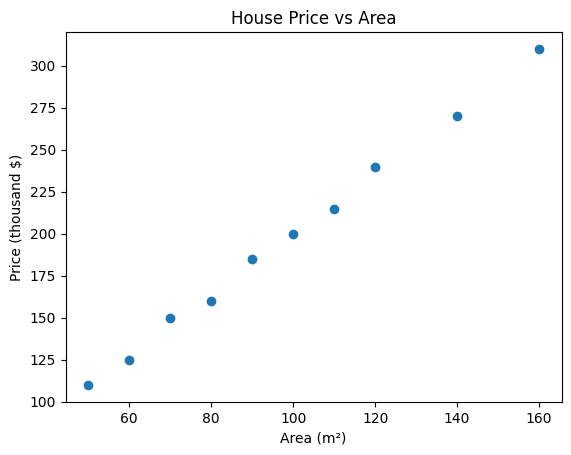

In [5]:
import matplotlib.pyplot as plt

plt.scatter(area, price)
plt.xlabel("Area (m²)")
plt.ylabel("Price (thousand $)")
plt.title("House Price vs Area")
plt.show()

## Exercise 3: Prediction function (5 marks)

Complete the function `predict(x, w, b)` so that it returns $w \cdot x + b$.

In [10]:
def predict(x, w, b):
    y_hat = w * x + b
    return y_hat

**Check (given, do not change).** If your function is correct, this prints **190.0**.

In [11]:
print(predict(1.0, 150, 40))

190.0


## Exercise 4: Cost function (15 marks)

**(a)** Complete the function `compute_cost(x, y, w, b)`. It must return **(10 marks)**

$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} \left(\hat{y}_i - y_i\right)^2$$

Steps: predict, find the errors, square them, add them up, divide by `2 * m`.

In [12]:
def compute_cost(x, y, w, b):
    m = len(x)
    predictions = predict(x, w, b)
    errors = predictions - y
    cost = np.sum(errors ** 2) / (2 * m)
    return cost

**(b)** Use your function to compute and print the cost for these two lines **(3 marks)**:

- Line 1: `w = 0`, `b = 0`
- Line 2: `w = 150`, `b = 40`

Check: for Line 1 you should get about **22704.67**, and for Line 2 about **11.96**.

In [13]:
cost_line1 = compute_cost(x, y, 0, 0)
cost_line2 = compute_cost(x, y, 150, 40)

print("Cost of line 1:", cost_line1)
print("Cost of line 2:", cost_line2)

Cost of line 1: 22704.666666666668
Cost of line 2: 11.958333333333334


**(c)** Which line is better, Line 1 or Line 2? Explain in one sentence. **(2 marks)**

**Your answer:**

*(write your answer here)*

## Exercise 5: Gradients (15 marks)

**(a)** Complete the function `compute_gradients(x, y, w, b)`. It must return `dw` and `db` **(10 marks)**:

$$dw = \frac{1}{m} \sum_{i=1}^{m} \left(\hat{y}_i - y_i\right) \cdot x_i \qquad\qquad db = \frac{1}{m} \sum_{i=1}^{m} \left(\hat{y}_i - y_i\right)$$

In [14]:
def compute_gradients(x, y, w, b):
    m = len(x)
    predictions = predict(x, w, b)
    errors = predictions - y
    dw = np.sum(errors * x) / m
    db = np.sum(errors) / m
    return dw, db


**(b)** Compute and print the gradients at `w = 0`, `b = 0`. **(3 marks)**

Check: you should get about **dw = -247.10** and **db = -202.33**.

In [15]:
dw, db = compute_gradients(x, y, 0, 0)

print("dw =", dw)
print("db =", db)

dw = -247.1
db = -202.33333333333334


**(c)** Both gradients are negative. Using the update rule, will `w` and `b` go **up** or **down** after the first step? Explain in one sentence. **(2 marks)**

**Your answer:**

*(write your answer here)*

## Exercise 6: Gradient descent loop (15 marks)

Complete the training loop. Start with `w = 0`, `b = 0`, use `learning_rate = 0.5` and `iterations = 1000`.

- **(a)** Compute the gradients, then update `w` and `b` with the update rule. **(8 marks)**
- **(b)** Compute the cost and add it to `cost_history`. **(4 marks)**
- **(c)** After the loop, print the final `w`, `b` and cost (rounded to 2 decimals). **(3 marks)**

Hint: look at section A10 in Part A.

In [16]:
w = 0
b = 0
learning_rate = 0.5
iterations = 1000

cost_history = []

for i in range(iterations):
    dw, db = compute_gradients(x, y, w, b)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    cost = compute_cost(x, y, w, b)
    cost_history.append(cost)

    if i % 100 == 0:
        print("Iteration", i, ": cost =", round(cost, 2))

print("Final w:", round(w, 2))
print("Final b:", round(b, 2))
print("Final cost:", round(cost, 2))


Iteration 0 : cost = 582.68
Iteration 100 : cost = 11.39
Iteration 200 : cost = 11.36
Iteration 300 : cost = 11.36
Iteration 400 : cost = 11.36
Iteration 500 : cost = 11.36
Iteration 600 : cost = 11.36
Iteration 700 : cost = 11.36
Iteration 800 : cost = 11.36
Iteration 900 : cost = 11.36
Final w: 150.31
Final b: 40.75
Final cost: 11.36


## Exercise 7: Regression line and cost-convergence curve (10 marks)

- **(a)** Draw the data as a scatter plot and your regression line on top of it, in one plot. Add axis labels, a title and a legend. **(5 marks)**

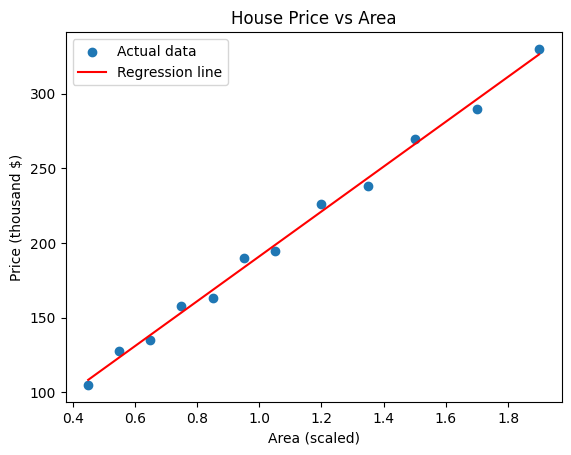

In [17]:
import matplotlib.pyplot as plt

x_line = np.linspace(np.min(x), np.max(x), 100)

plt.scatter(x, y, label="Actual data")
plt.plot(x_line, predict(x_line, w, b), color="red", label="Regression line")
plt.xlabel("Area (scaled)")
plt.ylabel("Price (thousand $)")
plt.title("House Price vs Area")
plt.legend()
plt.show()

- **(b)** Plot the cost-convergence curve (`cost_history`). Add axis labels and a title. **(5 marks)**

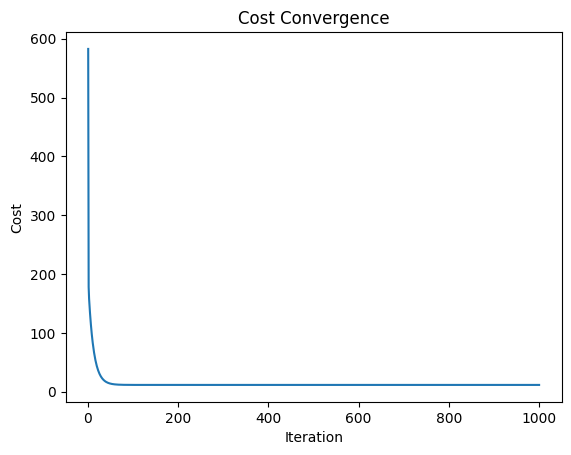

In [18]:
plt.plot(range(1, len(cost_history) + 1), cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Convergence")
plt.show()

## Exercise 8: Predictions (5 marks)

Use your trained `w` and `b` to predict the price of two new houses:

- House A: **100 m2**
- House B: **180 m2**

Remember to scale the area first. Print each predicted price rounded to 1 decimal.

In [19]:
price_a = predict(100 / 100, w, b)
price_b = predict(180 / 100, w, b)

print("House A:", round(price_a, 1), "thousand $")
print("House B:", round(price_b, 1), "thousand $")

House A: 191.1 thousand $
House B: 311.3 thousand $


## Exercise 9: Learning rate experiment (10 marks)

The `train` function below is **given** (do not change it). It uses your `compute_gradients` and `compute_cost` functions and returns `w`, `b` and `cost_history`.

In [20]:
def train(x, y, learning_rate, iterations):
    w = 0
    b = 0
    cost_history = []
    for i in range(iterations):
        dw, db = compute_gradients(x, y, w, b)
        w = w - learning_rate * dw
        b = b - learning_rate * db
        cost_history.append(compute_cost(x, y, w, b))
    return w, b, cost_history

- **(a)** Train the model **twice** for **100 iterations**: once with `learning_rate = 0.01` and once with `learning_rate = 0.5`. Plot both cost curves **on the same plot**, with labels, a title and a legend. **(4 marks)**

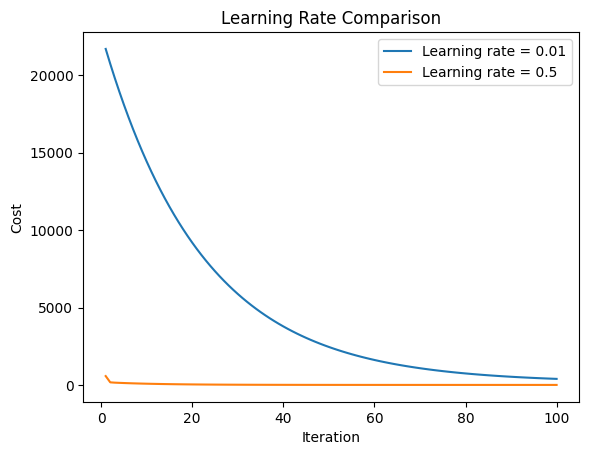

In [21]:
w_slow, b_slow, cost_slow = train(x, y, 0.01, 100)
w_fast, b_fast, cost_fast = train(x, y, 0.5, 100)

plt.plot(range(1, 101), cost_slow, label="Learning rate = 0.01")
plt.plot(range(1, 101), cost_fast, label="Learning rate = 0.5")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

- **(b)** Train the model with `learning_rate = 1.2` for **10 iterations** and print the cost at each iteration. **(2 marks)**

In [22]:
w_large, b_large, cost_large = train(x, y, 1.2, 10)

for i, cost in enumerate(cost_large, start=1):
    print("Iteration", i, ": cost =", round(cost, 2))

Iteration 1 : cost = 66637.33
Iteration 2 : cost = 196495.9
Iteration 3 : cost = 580164.4
Iteration 4 : cost = 1713576.82
Iteration 5 : cost = 5061729.36
Iteration 6 : cost = 14952236.07
Iteration 7 : cost = 44168910.03
Iteration 8 : cost = 130475252.88
Iteration 9 : cost = 385424993.87
Iteration 10 : cost = 1138548866.93


- **(c)** Describe what happened with each of the three learning rates (0.01, 0.5 and 1.2). Which one is the best, and why? Write 2 to 3 sentences. **(4 marks)**

**Your answer:**

*(0.01 learns slow, but 0.5 learns much faster. With 1.2 the steps are too big and cost goes up. 0.5 is best because its fast and stable.)*

## Exercise 10: Theory questions (10 marks)

Answer each question in 1 to 3 sentences. **2 marks each.**

**Q1.** In the model $\hat{y} = w \cdot x + b$ for house prices, what do $w$ and $b$ mean?

**Your answer:**

*(w is the slope, how much predicted price changes when x goes up by 1. b is the predicted price when x is 0.)*

**Q2.** What does the cost function measure? Why do we **square** the errors?

**Your answer:**

*(Cost shows how far predictions are from real prices. We square errors so positives and negatives dont cancel out, and big errors count more)*

**Q3.** What is the learning rate? What happens if it is too small, and what happens if it is too large?

**Your answer:**

*(Learning rate is the step size for updating w and b. Too small learns slow, too big can overshoot and make cost go up.)*

**Q4.** Why did we divide the area by 100 before training? What must we remember to do when we predict the price of a new house?

**Your answer:**

*(We divided by 100 to make numbers smaller so training is more stable. For a new house we need to divide its area by 100 too)*

**Q5.** Looking at the cost-convergence curve, how can you tell that gradient descent has finished learning (converged)?

**Your answer:**

*(The curve becomes almost flat and cost barely changes anymore. This means the model has mostly stopped improving.)*

---
**End of lab.** Before submitting, click **Runtime > Restart and run all** and check that every cell runs without errors.